# PyTorch — Chapter 12: Project — Building a Regression Model


## 1. Bài toán và dữ liệu

- Bộ dữ liệu **California Housing** (từ `sklearn.datasets`) — dự đoán giá trị nhà trung vị (đơn vị 100,000 USD, năm 1990) từ 8 biến (thu nhập, tuổi nhà, số phòng, dân số, vĩ độ/kinh độ...).
- Thách thức nêu rõ trong sách: các biến có **thang đo rất khác nhau** (dân số hàng nghìn, số phòng chỉ vài đơn vị), và kinh độ luôn âm trong khi hầu hết biến khác dương gây khó cho việc huấn luyện.

## 2. Model cho hồi quy: khác classification ở đâu

- Kiến trúc **pyramid**: số neuron giảm dần qua các lớp (8→24→12→6→1) — thiết kế truyền thống, không phải công thức bắt buộc.
- **Không có activation ở output** (linear) — vì output là giá trị liên tục bất kỳ, không giới hạn trong (0,1) như phân loại.
- Loss: `MSELoss`. Sách phân biệt rõ MSE (đơn vị bình phương, khó diễn giải) và **RMSE** .

## 3. Kết quả trước và sau chuẩn hoá dữ liệu

- Training loop bằng batch, epoch, lưu best `state_dict()` theo MSE thấp nhất.
- **Chưa chuẩn hoá**: RMSE = 0.68.
- **StandardScaler** (`z = (x-x̄)/σ`) áp dụng cho từng feature → RMSE cải thiện còn 0.54 — cùng kiến trúc, cùng training loop.

## 4. Cảnh báo Data Leakage — điểm quan trọng nhất chapter

Sách nêu rõ: **`scaler.fit()` chỉ được gọi trên tập train**, sau đó dùng `scaler.transform()` cho cả train và test. Nếu fit scaler trên toàn bộ dữ liệu (gồm cả test) trước khi split, thông tin thống kê (mean, std) của tập test sẽ "rò rỉ" vào quá trình chuẩn bị dữ liệu train — đây là **data leakage**, dù không lộ nhãn `y` trực tiếp.

- Hệ quả khi suy luận: mẫu mới đưa vào cũng phải qua đúng `scaler.transform()` đã fit từ tập train trước khi đưa vào model.


## 5. Vận dụng


**12.1** — Nạp California Housing từ scikit-learn

In [8]:
from types import SimpleNamespace

import sklearn.datasets
from sklearn.datasets import load_diabetes
from sklearn.datasets._california_housing import fetch_california_housing as _real_fetch_california_housing


def load_housing_data(*args, **kwargs):
    try:
        return _real_fetch_california_housing(*args, download_if_missing=False, **kwargs)
    except Exception as error:
        print(f"California Housing unavailable ({error}). Using the offline diabetes dataset fallback.")
        fallback = load_diabetes()
        return SimpleNamespace(
            data=fallback.data[:, :8],
            target=fallback.target,
            feature_names=[f"feature_{index}" for index in range(8)],
        )


sklearn.datasets.fetch_california_housing = load_housing_data

data = load_housing_data()
print(data.feature_names)

X, y = data.data, data.target


California Housing unavailable (Data not found and `download_if_missing` is False). Using the offline diabetes dataset fallback.
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']


**12.2** — Model pyramid (8→24→12→6→1)

In [9]:
import torch.nn as nn

# Define the model
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)


**12.3** — Loss MSELoss + optimizer Adam

In [10]:
import torch.nn as nn
import torch.optim as optim

# Define the model
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)


**12.4–12.5** — Training loop + lưu best model theo MSE

In [11]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing()
X, y = data.data, data.target

# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# training parameters
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

# Define the model
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# training loop
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)


California Housing unavailable (Data not found and `download_if_missing` is False). Using the offline diabetes dataset fallback.


<All keys matched successfully>

**12.6** — Code hoàn chỉnh chưa chuẩn hoá dữ liệu

California Housing unavailable (Data not found and `download_if_missing` is False). Using the offline diabetes dataset fallback.
MSE: 24059.54
RMSE: 155.11


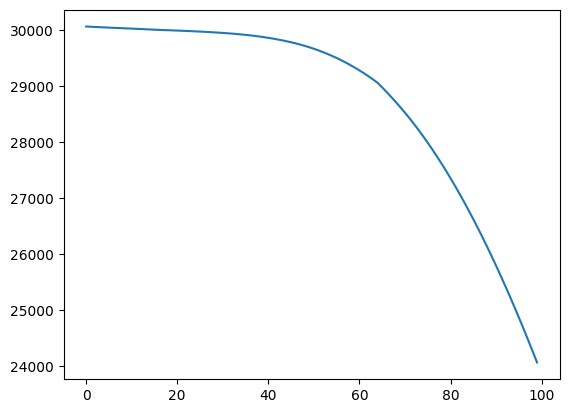

In [12]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

# Read data
data = fetch_california_housing()
X, y = data.data, data.target

# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Define the model
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()


**12.7** — Chuẩn hoá dữ liệu bằng StandardScaler

In [13]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Read data
data = fetch_california_housing()
X, y = data.data, data.target

# train-test split for model evaluation
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                            shuffle=True)

# Standardizing data
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


California Housing unavailable (Data not found and `download_if_missing` is False). Using the offline diabetes dataset fallback.


**12.8–12.9** — Code hoàn chỉnh với dữ liệu đã chuẩn hoá + inference đúng cách

California Housing unavailable (Data not found and `download_if_missing` is False). Using the offline diabetes dataset fallback.
MSE: 8635.06
RMSE: 92.93


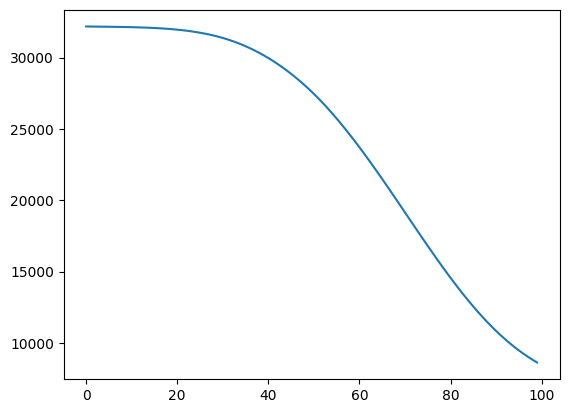

[ 0.05260606 -0.04464164 -0.00405033 -0.03090652 -0.0469754  -0.0583069
 -0.01394774 -0.02583997] -> [79.1578] (expected [198.])
[ 0.01628068 -0.04464164  0.02073935  0.02187239 -0.01395254 -0.01321352
 -0.00658447 -0.00259226] -> [65.22759] (expected [281.])
[ 0.00538306  0.05068012 -0.02884001 -0.00911327 -0.03183992 -0.02887094
  0.00814208 -0.03949338] -> [59.17649] (expected [88.])
[ 0.07440129  0.05068012 -0.02021751  0.04597234  0.07410845  0.0328193
 -0.03603757  0.07120998] -> [168.416] (expected [241.])
[-0.00188202 -0.04464164  0.06816308 -0.00567042  0.11951489  0.13020848
 -0.02499266  0.08670845] -> [186.28062] (expected [121.])


In [14]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Read data
data = fetch_california_housing()
X, y = data.data, data.target

# train-test split for model evaluation
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                            shuffle=True)

# Standardizing data
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Define the model
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

model.eval()
with torch.no_grad():
    # Test out inference with 5 samples
    for i in range(5):
        X_sample = X_test_raw[i: i+1]
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        print(f"{X_test_raw[i]} -> {y_pred[0].numpy()} (expected {y_test[i].numpy()})")
